1. label encoding
2. 결측치 확인, 제거
3. Dubel 개수확인
4. feature selection

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week3/titanic.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [27]:
df.isnull().sum() #결측치 개수 확인

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
#결측치가 너무 많아서 평균값 의미 없다 판단
df=df.drop('Cabin',axis=1)

In [29]:
# Age 결측값에 평균값 넣기
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [30]:
df.isnull().sum() #결측치 개수 확인

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [31]:
#안채워진 결측값 있는 행 삭제
#현재 결측값이 없음으로 안해도됨
#df = df.dropna()

In [32]:
#성별은 중요한 feature이기 때문에 남자는 0, 여자는 1로 변환
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [33]:
# Embarked의 행 2개는 최빈값으로 널기
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [34]:
# 성별은 2개라 0,1로 나누면 되지만 Embarked는 3개임으로 map이 아닌 원-핫 인코딩으로 변환
# 최빈값이 아닌 평균값을 넣고싶다면 아래 행을 실행 후 평균값 대입 가능
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000000,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000000,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.000000,0,0,373450,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000000,0,0,211536,13.0000,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000000,0,0,112053,30.0000,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29.699118,1,2,W./C. 6607,23.4500,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000000,0,0,111369,30.0000,1,0,0


중요한 값만 X값에 넣기 - Pclass,sex,age,sipsp,parch,fare,embarked 가 의미있으면서 모델에 적용 가능한 값인데 Embarked(항구), Fare(요금)의 경우 Pclass에 의해 중요도가 떨어진다 판단하여 제외

In [35]:
#cabin은 자료가 거의 없음
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket','Fare','Embarked_C','Embarked_Q','Embarked_S'], axis=1)
y = df['Survived']
X

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.000000,1,0
1,1,1,38.000000,1,0
2,3,1,26.000000,0,0
3,1,1,35.000000,1,0
4,3,0,35.000000,0,0
...,...,...,...,...,...
886,2,0,27.000000,0,0
887,1,1,19.000000,0,0
888,3,1,29.699118,1,2
889,1,0,26.000000,0,0


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

Ti_lr= LogisticRegression(random_state=0, max_iter=5000)
Ti_lr.fit(X_train, y_train)

pred_lr = Ti_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7982062780269058
[[116  23]
 [ 22  62]]


In [38]:
from sklearn.tree import DecisionTreeClassifier

Ti_dt = DecisionTreeClassifier(random_state=0)
Ti_dt.fit(X_train, y_train)

pred_dt = Ti_dt.predict(X_test)

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- DecisionTreeClassifier ---
0.7847533632286996
[[120  19]
 [ 29  55]]


In [39]:
from sklearn.ensemble import RandomForestClassifier

Ti_rt = RandomForestClassifier(random_state=0)
Ti_rt.fit(X_train, y_train)

pred_rt = Ti_rt.predict(X_test)

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_rt))
print (confusion_matrix(y_test, pred_rt))


--- RandomForestClassifier ---
0.7937219730941704
[[115  24]
 [ 22  62]]


In [40]:
from sklearn.neighbors import KNeighborsClassifier

Ti_knn = KNeighborsClassifier(n_neighbors=5)
Ti_knn.fit(X_train, y_train)

pred_knn = Ti_knn.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))


--- KNeighborsClassifier ---
0.7623318385650224
[[119  20]
 [ 33  51]]



--- KNeighborsClassifier 최적화 결과 ---
최적의 k: 9
최고 정확도: 0.7937219730941704

--- KNeighborsClassifier ---
정확도: 0.7937219730941704
혼동행렬:
 [[124  15]
 [ 31  53]]


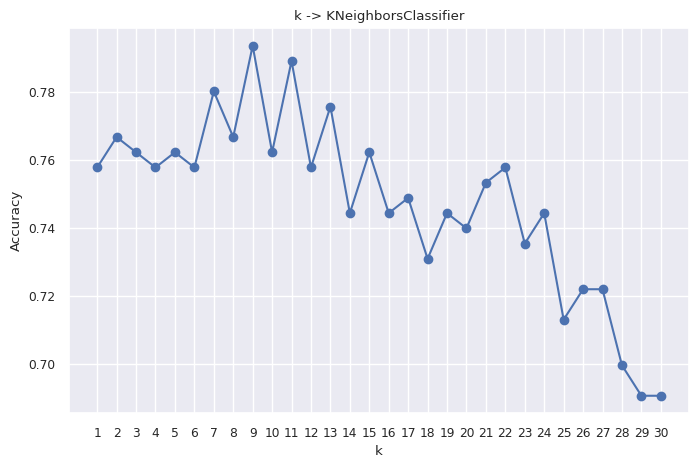

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

k_list = []
acc_list = []

#최적 k 찾기
for k in range(1, 31):
    Ti_knn = KNeighborsClassifier(n_neighbors=k)
    Ti_knn.fit(X_train, y_train)

    pred_knn = Ti_knn.predict(X_test)

    acc = accuracy_score(y_test, pred_knn)

    k_list.append(k)
    acc_list.append(acc)

best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)

print("\n--- KNeighborsClassifier 최적화 결과 ---")
print("최적의 k:", best_k)
print("최고 정확도:", best_acc)

# 최적 k로 다시 학습
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print("\n--- KNeighborsClassifier ---")
print("정확도:", accuracy_score(y_test, pred_knn))
print("혼동행렬:\n", confusion_matrix(y_test, pred_knn))

# 그래프
plt.figure(figsize=(8, 5))
plt.plot(k_list, acc_list, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k -> KNeighborsClassifier")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

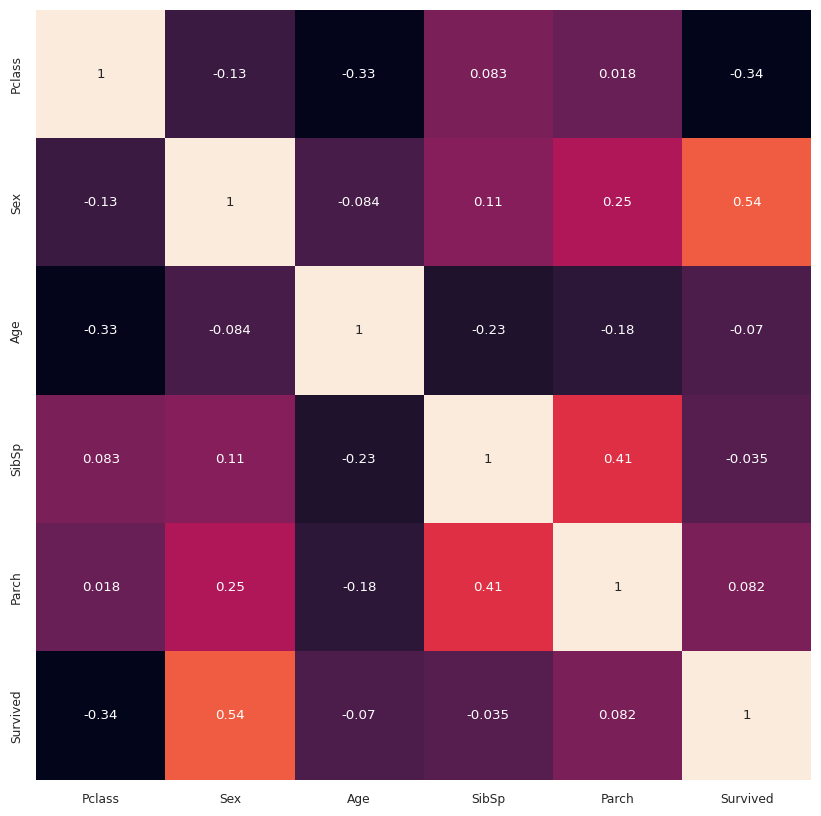

In [42]:
import seaborn as sns

#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc

아래는 다 넣은거

In [43]:
#class,sex,age,sipsp,parch,fare,embarked
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)
y = df['Survived']
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.000000,1,0,7.2500,0,0,1
1,1,1,38.000000,1,0,71.2833,1,0,0
2,3,1,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,3,0,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,0,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,3,1,29.699118,1,2,23.4500,0,0,1
889,1,0,26.000000,0,0,30.0000,1,0,0


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

Ti_lr= LogisticRegression(random_state=0, max_iter=5000)
Ti_lr.fit(X_train, y_train)

pred_lr = Ti_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7937219730941704
[[116  23]
 [ 23  61]]


In [46]:
from sklearn.tree import DecisionTreeClassifier

Ti_dt = DecisionTreeClassifier(random_state=0)
Ti_dt.fit(X_train, y_train)

pred_dt = Ti_dt.predict(X_test)

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- DecisionTreeClassifier ---
0.7623318385650224
[[113  26]
 [ 27  57]]


In [47]:
from sklearn.ensemble import RandomForestClassifier

Ti_rt = RandomForestClassifier(random_state=0)
Ti_rt.fit(X_train, y_train)

pred_rt = Ti_rt.predict(X_test)

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_rt))
print (confusion_matrix(y_test, pred_rt))


--- RandomForestClassifier ---
0.8295964125560538
[[123  16]
 [ 22  62]]


In [48]:
from sklearn.neighbors import KNeighborsClassifier

Ti_knn = KNeighborsClassifier(n_neighbors=5)
Ti_knn.fit(X_train, y_train)

pred_knn = Ti_knn.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))


--- KNeighborsClassifier ---
0.726457399103139
[[112  27]
 [ 34  50]]



--- KNeighborsClassifier 최적화 결과 ---
최적의 k: 19
최고 정확도: 0.7757847533632287

--- KNeighborsClassifier ---
정확도: 0.7757847533632287
혼동행렬:
 [[125  14]
 [ 36  48]]


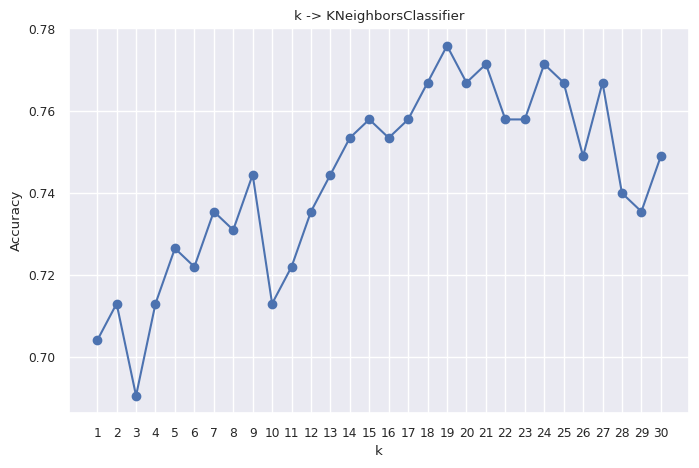

In [49]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

k_list = []
acc_list = []

#최적 k 찾기
for k in range(1, 31):
    Ti_knn = KNeighborsClassifier(n_neighbors=k)
    Ti_knn.fit(X_train, y_train)

    pred_knn = Ti_knn.predict(X_test)

    acc = accuracy_score(y_test, pred_knn)

    k_list.append(k)
    acc_list.append(acc)

best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)

print("\n--- KNeighborsClassifier 최적화 결과 ---")
print("최적의 k:", best_k)
print("최고 정확도:", best_acc)

# 최적 k로 다시 학습
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print("\n--- KNeighborsClassifier ---")
print("정확도:", accuracy_score(y_test, pred_knn))
print("혼동행렬:\n", confusion_matrix(y_test, pred_knn))

# 그래프
plt.figure(figsize=(8, 5))
plt.plot(k_list, acc_list, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k -> KNeighborsClassifier")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

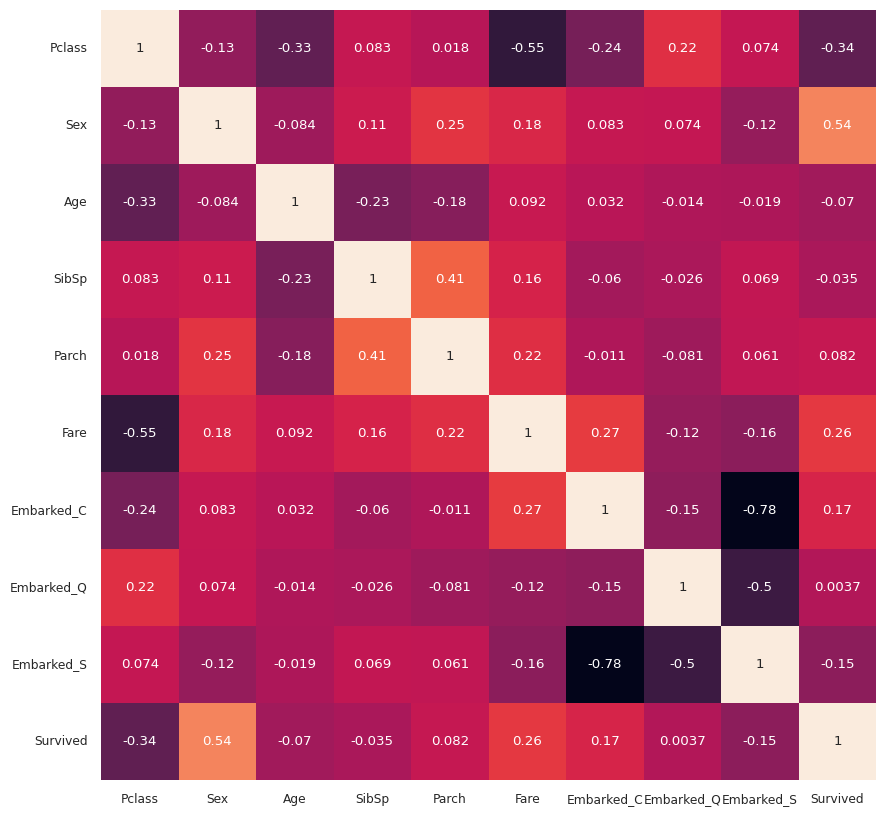

In [50]:
import seaborn as sns

#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc